# Convert and Optimize YOLO26 real-time object detection with OpenVINO™

Real-time object detection is often used as a key component in computer vision systems.
Applications that use real-time object detection models include video analytics, robotics, autonomous vehicles, multi-object tracking and object counting, medical image analysis, and many others.


This tutorial demonstrates step-by-step instructions on how to run and optimize PyTorch YOLO26 with OpenVINO. We consider the steps required for object detection scenario. You can find more details about model on [model page](https://docs.ultralytics.com/models/yolo26/) in Ultralytics documentation.

[YOLO26](https://docs.ultralytics.com/models/yolo26/) is the latest Ultralytics release (January 2026), engineered for edge and low-power devices. It is now the **recommended model** for production workloads, replacing both YOLO11 and YOLO12. Key innovations include:
- **End-to-End NMS-Free Inference** — native end-to-end predictions without non-maximum suppression (NMS), reducing latency and simplifying deployment.
- **Dual-Head Architecture** — one-to-one head (default, no NMS, max 300 detections) and one-to-many head (legacy, requires NMS, 8400 detections).
- **DFL Removal** — Distribution Focal Loss module removed, simplifying export and broadening edge hardware compatibility.
- **MuSGD Optimizer** — hybrid of SGD and Muon (inspired by Moonshot AI's Kimi K2) for more stable training and faster convergence.
- **ProgLoss + STAL** — improved loss functions with notable improvements in small-object detection.
- **Up to 43% Faster CPU Inference** — specifically optimized for edge computing environments.
- **Instance Segmentation, Pose, OBB Enhancements** — semantic segmentation loss, RLE for pose estimation, angle loss for OBB.
- **YOLOE-26** — open-vocabulary variant supporting text/visual prompts and prompt-free zero-shot inference.

YOLO26 supports detection, instance segmentation, classification, pose estimation, oriented object detection (OBB), and open-vocabulary detection (YOLOE-26).


#### Table of contents:

- [Get PyTorch model](#Get-PyTorch-model)
    - [Prerequisites](#Prerequisites)
- [Instantiate model](#Instantiate-model)
    - [Convert model to OpenVINO IR](#Convert-model-to-OpenVINO-IR)
    - [Verify model inference](#Verify-model-inference)
    - [Select inference device](#Select-inference-device)
    - [Test on single image](#Test-on-single-image)
- [Optimize model using NNCF Post-training Quantization API](#Optimize-model-using-NNCF-Post-training-Quantization-API)
    - [Validate Quantized model inference](#Validate-Quantized-model-inference)
- [Compare performance of object detection models](#Compare-performance-of-object-detection-models)
- [Next steps](#Next-steps)
    - [Async inference pipeline](#Async-inference-pipeline)
- [Live demo](#Live-demo)
    - [Run Live Object Detection](#Run-Live-Object-Detection)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/yolov26-optimization/yolov26-object-detection.ipynb" />

## Get PyTorch model
[back to top ⬆️](#Table-of-contents:)

Generally, PyTorch models represent an instance of the [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class, initialized by a state dictionary with model weights.
We will use the YOLO26 nano model (also known as `yolo26n`) pre-trained on a COCO dataset, which is available in this [repo](https://github.com/ultralytics/ultralytics). Similar steps are also applicable to other YOLO26 models.
Typical steps to obtain a pre-trained model:
1. Create an instance of a model class.
2. Load a checkpoint state dict, which contains the pre-trained model weights.
3. Turn the model to evaluation for switching some operations to inference mode.

In this case, Ultralytics provides an API that enables converting the YOLO26 model to OpenVINO IR. Therefore, we do not need to do these steps manually.

#### Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install necessary packages.

In [1]:
%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.43" tqdm opencv-python

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Import required utility functions.
The lower cell will download the `notebook_utils` Python module from GitHub.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, VideoPlayer, device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yolov26-object-detection.ipynb")

In [3]:
# Download a test sample
IMAGE_PATH = Path("./data/coco_bike.jpg")

if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

coco_bike.jpg:   0%|          | 0.00/182k [00:00<?, ?B/s]

## Instantiate model
[back to top ⬆️](#Table-of-contents:)

For loading the model, required to specify a path to the model checkpoint. It can be some local path or name available on models hub (in this case model checkpoint will be downloaded automatically).

Making prediction, the model accepts a path to input image and returns list with Results class object. Results contains boxes for object detection. Also it contains utilities for processing results, for example, `plot()` method for drawing.

Let us consider the examples:

In [4]:
import ipywidgets as widgets

model_id = ["yolo26n", "yolo26s", "yolo26m", "yolo26l", "yolo26x"]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yolo26n', 'yolo26s', 'yolo26m', 'yolo26l', 'yolo26x'), value='yolo26n'…

image 1/1 /home/amd/Desktop/OpenVINO-Notebooks-on-AMD/results/yolov26-object-detection/workdir-cpu/data/coco_bike.jpg: 480x640 2 bicycles, 2 cars, 1 dog, 37.8ms


Speed: 1.3ms preprocess, 37.8ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)


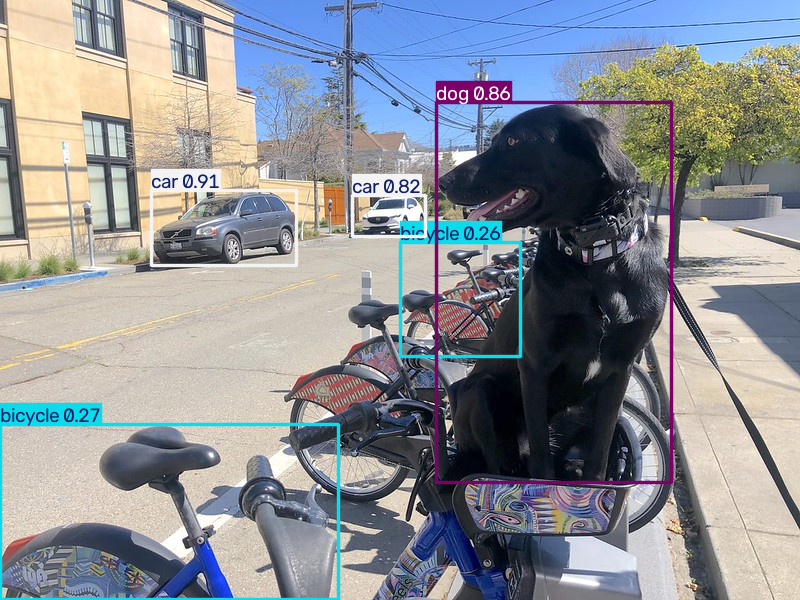

In [5]:
from PIL import Image
from ultralytics import YOLO

DET_MODEL_NAME = model_name.value

det_model = YOLO(f"{DET_MODEL_NAME}.pt")
det_model.to("cpu")
label_map = det_model.model.names

res = det_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

### Convert model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Ultralytics provides the `model.export()` method for converting models to OpenVINO IR format. Key parameters for YOLO26:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `format` | `"openvino"` | Target export format |
| `half` | `True` | Export weights in FP16 precision for smaller model size and faster inference |
| `dynamic` | `True` / `False` | `dynamic=True` preserves the original preprocessing behavior (adaptive LetterBox padding) and produces results closest to the PyTorch model. `dynamic=False` uses fixed 640×640 input shape — required for NPU deployment and may improve throughput, but can slightly affect detection results due to different padding |
| `end2end` | `True` | **Required for YOLO26.** Exports NMS-free end-to-end model. YOLO26 uses a single one2one detection head, so `end2end=False` will cause a `KeyError` at export |

> **Note**: Unlike older YOLO versions (v8, v11) that support both `end2end=True` and `end2end=False`, YOLO26 is architecturally NMS-free and only works with `end2end=True`.

In [6]:
# object detection model
det_model_path = Path(f"{DET_MODEL_NAME}_openvino_model/{DET_MODEL_NAME}.xml")
if not det_model_path.exists():
    det_model.export(format="openvino", dynamic=False, half=True, end2end=True)

Ultralytics 8.4.43 🚀 Python-3.12.3 torch-2.10.0+cpu CPU (AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S)



PyTorch: starting from 'yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.3 MB)



OpenVINO: starting export with openvino 2026.4.1-22982-e213a147257-releases/2026/4...


OpenVINO: export success ✅ 1.6s, saved as 'yolo26n_openvino_model/' (5.1 MB)



Export complete (1.7s)
Results saved to /home/amd/Desktop/OpenVINO-Notebooks-on-AMD/results/yolov26-object-detection/workdir-cpu
Predict:         yolo predict task=detect model=yolo26n_openvino_model/ imgsz=640 half
Validate:        yolo val task=detect model=yolo26n_openvino_model/ imgsz=640 data=/home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml half 
Visualize:       https://netron.app


### Verify model inference
[back to top ⬆️](#Table-of-contents:)

We can reuse the base model pipeline specifying Intel devices (intel:gpu, intel:npu, intel:cpu) when running inference with OpenVINO.

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO.

In [7]:
device = device_widget()

device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

### Test on single image
[back to top ⬆️](#Table-of-contents:)

Now, once we have defined preprocessing and postprocessing steps, we are ready to check model prediction for object detection.

Loading yolo26n_openvino_model for OpenVINO inference...


Using OpenVINO LATENCY mode for batch=1 inference on CPU...


image 1/1 /home/amd/Desktop/OpenVINO-Notebooks-on-AMD/results/yolov26-object-detection/workdir-cpu/data/coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 7.2ms


Speed: 1.3ms preprocess, 7.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


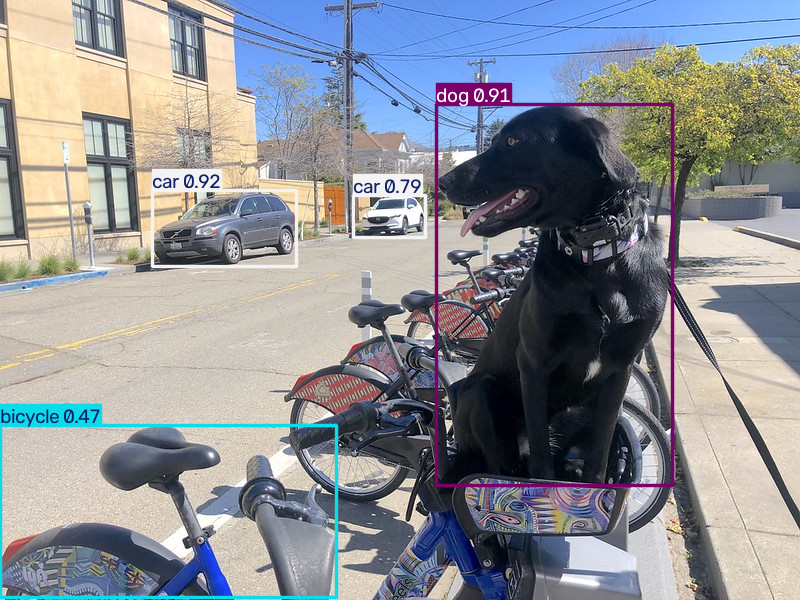

In [8]:
det_model = YOLO(det_model_path.parent, task="detect")

res = det_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])

## Optimize model using NNCF Post-training Quantization API
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides a suite of advanced algorithms for Neural Networks inference optimization in OpenVINO with minimal accuracy drop.
We will use 8-bit quantization in post-training mode (without the fine-tuning pipeline) to optimize model.

The optimization process contains the following steps:

1. Create a Dataset for quantization.
2. Run `nncf.quantize` for getting an optimized model.
3. Serialize OpenVINO IR model, using the `openvino.save_model` function.

Please select below whether you would like to run quantization to improve model inference speed.

In [9]:
int8_model_det_path = Path(f"{DET_MODEL_NAME}_openvino_model_int8/{DET_MODEL_NAME}.xml")
quantized_det_model = None

to_quantize = quantization_widget()
quantization_mode = widgets.Dropdown(
    options=[
        ("Default quantization", "default"),
        ("Quantization with accuracy control", "accuracy_control"),
    ],
    value="default",
    description="Mode",
)

widgets.VBox([to_quantize, quantization_mode])

Let's load `skip magic` extension to skip quantization if `to_quantize` is not selected

In [10]:
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

Prepare calibration dataset for quantization. We download a small dataset and wrap it into the `nncf.Dataset` object with a transformation function for getting input tensors.

In [11]:
%%skip not $to_quantize.value

import cv2
import numpy as np
from zipfile import ZipFile
from pathlib import Path
from notebook_utils import use_local_ultralytics_datasets
from ultralytics.data.augment import LetterBox

OUT_DIR = use_local_ultralytics_datasets()

DATA_URL = "https://ultralytics.com/assets/coco128.zip"
DATA_PATH = OUT_DIR / "coco128.zip"

if not int8_model_det_path.exists():
    if not (OUT_DIR / "coco128").exists():
        download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
        with ZipFile(DATA_PATH, "r") as zip_ref:
            zip_ref.extractall(OUT_DIR)

    image_files = list((OUT_DIR / "coco128" / "images" / "train2017").glob("*.jpg"))

    def transform_fn(image_path):
        img = cv2.imread(str(image_path))
        img = LetterBox((640, 640))(image=img)
        img = img.transpose(2, 0, 1)  # HWC to CHW
        img = img[::-1]  # BGR to RGB
        img = np.ascontiguousarray(img, dtype=np.float32) / 255.0
        return np.expand_dims(img, 0)

coco128.zip:   0%|          | 0.00/6.66M [00:00<?, ?B/s]

The `nncf.quantize` function provides an interface for model quantization. It requires an instance of the OpenVINO Model and quantization dataset.
Optionally, some additional parameters for the configuration quantization process (number of samples for quantization, preset, ignored scope, etc.) can be provided. Ultralytics models contain non-ReLU activation functions, which require asymmetric quantization of activations. To achieve a better result, we will use a `mixed` quantization preset. It provides symmetric quantization of weights and asymmetric quantization of activations.

Following the [NNCF optimal settings for YOLO26](https://github.com/openvinotoolkit/nncf/tree/develop/examples/post_training_quantization/openvino/yolo26), we also disable `fast_bias_correction` and add the `.*one2one.*` pattern to `ignored_scope` to prevent accuracy degradation in the NMS-free detection head.

>**Note**: Model post-training quantization is a time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [12]:
%%skip not $to_quantize.value

import nncf
import shutil
import openvino as ov

if not int8_model_det_path.exists():
    core = ov.Core()
    ov_model = core.read_model(det_model_path)

    quantization_dataset = nncf.Dataset(image_files, transform_fn)
    calibration_dataset = quantization_dataset
    PRESET = nncf.QuantizationPreset.MIXED
    FAST_BIAS_CORRECTION = False
    IGNORED_SCOPE = nncf.IgnoredScope(patterns=[".*one2one.*"])
    use_accuracy_control = quantization_mode.value == "accuracy_control"

    # nncf with accuracy control
    if use_accuracy_control:
        import gc
        import torch
        from ultralytics.cfg import get_cfg
        from ultralytics.data.utils import check_det_dataset
        from ultralytics.models.yolo.detect import DetectionValidator
        from ultralytics.utils import YAML
        from ultralytics.utils.metrics import ConfusionMatrix

        MAX_DROP = 0.01
        DROP_TYPE = nncf.DropType.RELATIVE
        CALIB_SIZE = len(image_files)

        names = [label_map[index] for index in sorted(label_map)] if isinstance(label_map, dict) else list(label_map)
        data_yaml = OUT_DIR / "coco128_accuracy_control.yaml"
        if not data_yaml.exists():
            YAML.save(
                data_yaml,
                {
                    "path": str(OUT_DIR / "coco128"),
                    "train": "images/train2017",
                    "val": "images/train2017",
                    "names": names,
                },
            )

        args = get_cfg(
            overrides={
                "data": str(data_yaml),
                "batch": 1,
                "imgsz": 640,
                "task": "detect",
                "device": "cpu",
                "workers": 0,
                "plots": False,
                "verbose": False,
                "end2end": True,
            }
        )
        validator = DetectionValidator(args=args)
        validator.data = check_det_dataset(args.data)
        validator.stride = 32
        validator.names = names
        validator.metrics.names = names
        validator.nc = len(names)
        validator.device = torch.device("cpu")
        validator.end2end = True
        validator.args.workers = 0
        validation_loader = validator.get_dataloader(validator.data["val"], 1)

        def validation_transform_fn(data_item):
            batch = validator.preprocess(data_item)
            return batch["img"].numpy()

        validation_dataset = nncf.Dataset(validation_loader, validation_transform_fn)

        def reset_validator():
            validator.seen = 0
            validator.jdict = []
            validator.batch_i = 1
            validator.end2end = True
            validator.metrics.clear_stats()
            validator.metrics.clear_image_metrics()
            validator.confusion_matrix = ConfusionMatrix(names=names)

        def nncf_validation_fn(compiled_model, validation_subset) -> float:
            reset_validator()
            output = compiled_model.output(0)

            for batch in validation_subset:
                batch = validator.preprocess(batch)
                predictions = torch.from_numpy(compiled_model(batch["img"].numpy())[output])
                predictions = validator.postprocess(predictions)
                validator.update_metrics(predictions, batch)

            stats = validator.get_stats()
            map50_95 = stats["metrics/mAP50-95(B)"]
            print(f"[NNCF] mAP@50-95 = {map50_95:.4f}")
            gc.collect()
            return map50_95

    if not use_accuracy_control:
        quantized_det_model = nncf.quantize(
            ov_model,
            quantization_dataset,
            preset=PRESET,
            fast_bias_correction=FAST_BIAS_CORRECTION,
            ignored_scope=IGNORED_SCOPE,
        )
    else:
        quantized_det_model = nncf.quantize_with_accuracy_control(
            ov_model,
            calibration_dataset=calibration_dataset,
            validation_dataset=validation_dataset,
            validation_fn=nncf_validation_fn,
            max_drop=MAX_DROP,
            drop_type=DROP_TYPE,
            preset=PRESET,
            subset_size=CALIB_SIZE,
            fast_bias_correction=FAST_BIAS_CORRECTION,
            ignored_scope=IGNORED_SCOPE,
        )
        
    print(f"Quantized model will be saved to {int8_model_det_path}")
    ov.save_model(quantized_det_model, str(int8_model_det_path))
    shutil.copy(det_model_path.parent / "metadata.yaml", int8_model_det_path.parent / "metadata.yaml")

INFO:nncf:162 ignored nodes were found by patterns in the NNCFGraph


INFO:nncf:Not adding activation input quantizer for operation: 72 __module.model.23.one2one_cv2.0.0.conv/aten::_convolution/Convolution
82 __module.model.23.one2one_cv2.0.0.conv/aten::_convolution/Add
92 __module.model.23.one2one_cv2.2.1.act/aten::silu_/Swish



INFO:nncf:Not adding activation input quantizer for operation: 104 __module.model.23.one2one_cv2.0.1.conv/aten::_convolution/Convolution
114 __module.model.23.one2one_cv2.0.1.conv/aten::_convolution/Add
124 __module.model.23.one2one_cv2.2.1.act/aten::silu_/Swish_1



INFO:nncf:Not adding activation input quantizer for operation: 132 __module.model.23.one2one_cv2.0.2/aten::_convolution/Convolution
139 __module.model.23.one2one_cv2.0.2/aten::_convolution/Add



INFO:nncf:Not adding activation input quantizer for operation: 73 __module.model.23.one2one_cv3.0.0.0.conv/aten::_convolution/GroupConvolution
83 __module.model.23.one2one_cv3.0.0.0.conv/aten::_convolution/Add
93 __module.model.23.one2one_cv3.2.1.1.act/aten::silu_/Swish



...

INFO:nncf:Not adding activation input quantizer for operation: 412 __module.model.23.one2one_cv3.2.1.1.conv/aten::_convolution/Convolution
413 __module.model.23.one2one_cv3.2.1.1.conv/aten::_convolution/Add
414 __module.model.23.one2one_cv3.2.1.1.act/aten::silu_/Swish_11



INFO:nncf:Not adding activation input quantizer for operation: 415 __module.model.23.one2one_cv3.2.2/aten::_convolution/Convolution
416 __module.model.23.one2one_cv3.2.2/aten::_convolution/Add



Output()

Output()

Quantized model will be saved to yolo26n_openvino_model_int8/yolo26n.xml


### Validate Quantized model inference
[back to top ⬆️](#Table-of-contents:)

`nncf.quantize` returns the OpenVINO Model class instance, which is suitable for loading on a device for making predictions. `INT8` model input data and output result formats have no difference from the floating point model representation. Therefore, we can reuse the same `detect` function defined above for getting the `INT8` model result on the image.

Loading yolo26n_openvino_model_int8 for OpenVINO inference...


Using OpenVINO LATENCY mode for batch=1 inference on CPU...


image 1/1 /home/amd/Desktop/OpenVINO-Notebooks-on-AMD/results/yolov26-object-detection/workdir-cpu/data/coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 8.1ms


Speed: 1.6ms preprocess, 8.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


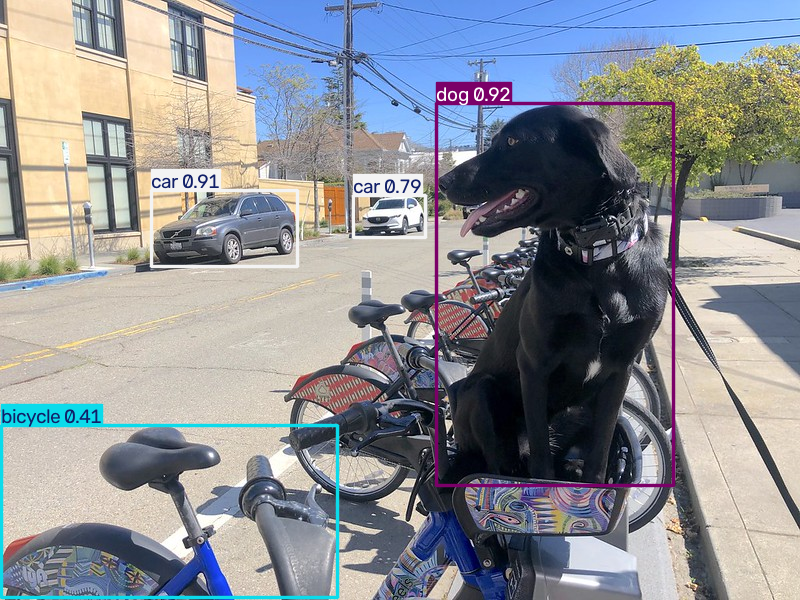

In [13]:
%%skip not $to_quantize.value

det_model = YOLO(int8_model_det_path.parent, task="detect")

res = det_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
display(Image.fromarray(res[0].plot()[:, :, ::-1]))

## Compare performance of object detection models
[back to top ⬆️](#Table-of-contents:)

Finally, use the OpenVINO [Benchmark Tool](https://docs.openvino.ai/2026/learn-openvino/openvino-samples/benchmark-tool.html) to measure the inference performance of the `FP16` and `INT8` models.

> **Note**: For more accurate performance, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications. Run `benchmark_app -m <model_path> -d CPU -shape "<input_shape>"` to benchmark async inference on CPU on specific input data shape for one minute. Change `CPU` to `GPU` to benchmark on GPU. Run `benchmark_app --help` to see an overview of all command-line options.

In [14]:
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [15]:
# Inference FP16 model (OpenVINO IR)
!benchmark_app -m $det_model_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.4.1-22982-e213a147257-releases/2026/4
[ INFO ] 
[ INFO ] Device info:


[ INFO ] CPU
[ INFO ] Build ................................. 2026.4.1-22982-e213a147257-releases/2026/4
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(CPU) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 17.55 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_4) : f32 / [...] / [1,300,6]
[Step 5/11] Resizing model to match image sizes and given batch
[ INFO ] Model batch size: 1
[ INFO ] Reshaping model: 'x': [1,3,640,640]
[ INFO ] Reshape model took 0.05 ms
[Step 6/11] Configuring input of the model
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : u8 / [N,C,H,W] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     **

[ INFO ] Compile model took 195.33 ms
[ INFO ] Start of compilation memory usage: Peak 5994112 KB
[ INFO ] End of compilation memory usage: Peak 7643548 KB
[ INFO ] Compile model ram used 1649436 KB
[Step 8/11] Querying optimal runtime parameters
[ INFO ] Model:
[ INFO ]   NETWORK_NAME: Model0
[ INFO ]   OPTIMAL_NUMBER_OF_INFER_REQUESTS: 8
[ INFO ]   NUM_STREAMS: 8
[ INFO ]   INFERENCE_NUM_THREADS: 32
[ INFO ]   PERF_COUNT: NO
[ INFO ]   INFERENCE_PRECISION_HINT: <Type: 'bfloat16'>
[ INFO ]   PERFORMANCE_HINT: THROUGHPUT
[ INFO ]   EXECUTION_MODE_HINT: ExecutionMode.PERFORMANCE
[ INFO ]   PERFORMANCE_HINT_NUM_REQUESTS: 0
[ INFO ]   ENABLE_CPU_PINNING: True
[ INFO ]   ENABLE_CPU_RESERVATION: False
[ INFO ]   SCHEDULING_CORE_TYPE: SchedulingCoreType.ANY_CORE
[ INFO ]   MODEL_DISTRIBUTION_POLICY: set()
[ INFO ]   ENABLE_HYPER_THREADING: True
[ INFO ]   EXECUTION_DEVICES: ['CPU']
[ INFO ]   CPU_DENORMALS_OPTIMIZATION: False
[ INFO ]   LOG_LEVEL: Level.NO
[ INFO ]   CPU_SPARSE_WEIGHTS_DECOM

[Step 11/11] Dumping statistics report
[ INFO ] Execution Devices:['CPU']
[ INFO ] Count:            6680 iterations
[ INFO ] Duration:         15026.06 ms
[ INFO ] Latency:
[ INFO ]    Median:        17.85 ms
[ INFO ]    Average:       17.85 ms
[ INFO ]    Min:           10.74 ms
[ INFO ]    Max:           46.10 ms
[ INFO ] Throughput:   444.56 FPS


In [16]:
if int8_model_det_path.exists():
    # Inference INT8 model (OpenVINO IR)
    !benchmark_app -m $int8_model_det_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.4.1-22982-e213a147257-releases/2026/4
[ INFO ] 
[ INFO ] Device info:


[ INFO ] CPU
[ INFO ] Build ................................. 2026.4.1-22982-e213a147257-releases/2026/4
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(CPU) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 29.00 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_4) : f32 / [...] / [1,300,6]
[Step 5/11] Resizing model to match image sizes and given batch
[ INFO ] Model batch size: 1
[ INFO ] Reshaping model: 'x': [1,3,640,640]
[ INFO ] Reshape model took 0.05 ms
[Step 6/11] Configuring input of the model
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : u8 / [N,C,H,W] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     **

[ INFO ] Compile model took 321.09 ms
[ INFO ] Start of compilation memory usage: Peak 5994112 KB
[ INFO ] End of compilation memory usage: Peak 7603580 KB
[ INFO ] Compile model ram used 1609468 KB
[Step 8/11] Querying optimal runtime parameters
[ INFO ] Model:
[ INFO ]   NETWORK_NAME: Model0
[ INFO ]   OPTIMAL_NUMBER_OF_INFER_REQUESTS: 8
[ INFO ]   NUM_STREAMS: 8
[ INFO ]   INFERENCE_NUM_THREADS: 32
[ INFO ]   PERF_COUNT: NO
[ INFO ]   INFERENCE_PRECISION_HINT: <Type: 'bfloat16'>
[ INFO ]   PERFORMANCE_HINT: THROUGHPUT
[ INFO ]   EXECUTION_MODE_HINT: ExecutionMode.PERFORMANCE
[ INFO ]   PERFORMANCE_HINT_NUM_REQUESTS: 0
[ INFO ]   ENABLE_CPU_PINNING: True
[ INFO ]   ENABLE_CPU_RESERVATION: False
[ INFO ]   SCHEDULING_CORE_TYPE: SchedulingCoreType.ANY_CORE
[ INFO ]   MODEL_DISTRIBUTION_POLICY: set()
[ INFO ]   ENABLE_HYPER_THREADING: True
[ INFO ]   EXECUTION_DEVICES: ['CPU']
[ INFO ]   CPU_DENORMALS_OPTIMIZATION: False
[ INFO ]   LOG_LEVEL: Level.NO
[ INFO ]   CPU_SPARSE_WEIGHTS_DECOM

[Step 11/11] Dumping statistics report
[ INFO ] Execution Devices:['CPU']
[ INFO ] Count:            8072 iterations
[ INFO ] Duration:         15018.39 ms
[ INFO ] Latency:
[ INFO ]    Median:        14.81 ms
[ INFO ]    Average:       14.70 ms
[ INFO ]    Min:           8.81 ms
[ INFO ]    Max:           26.47 ms
[ INFO ] Throughput:   537.47 FPS


## Next steps
[back to top ⬆️](#Table-of-contents:)

The performance could be also improved by another OpenVINO method such as async inference pipeline.

### Async inference pipeline
[back to top ⬆️](#Table-of-contents:)

The key advantage of the Async API is that when a device is busy with inference, the application can perform other tasks in parallel (for example, populating inputs or scheduling other requests) rather than wait for the current inference to complete first. To understand how to perform async inference using openvino, refer to [Async API tutorial](../async-api/async-api.ipynb).

## Live demo
[back to top ⬆️](#Table-of-contents:)

The following code runs model inference on a video:

In [17]:
import collections
import time
from IPython import display
import cv2
import numpy as np


# Main processing function to run object detection.
def run_object_detection(
    source=0,
    flip=False,
    use_popup=False,
    skip_first_frames=0,
    model=det_model,
    device=device.value,
    video_width: int = None,  # if not set the original size is used
):
    player = None

    try:
        # Create a video player to play with target fps.
        player = VideoPlayer(source=source, flip=flip, fps=30, skip_first_frames=skip_first_frames)
        # Start capturing.
        player.start()
        if use_popup:
            title = "Press ESC to Exit"
            cv2.namedWindow(winname=title, flags=cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()
        while True:
            # Grab the frame.
            frame = player.next()
            if frame is None:
                print("Source ended")
                break

            if video_width:
                # If the frame is larger than video_width, reduce size to improve the performance.
                scale = video_width / max(frame.shape)
                frame = cv2.resize(
                    src=frame,
                    dsize=None,
                    fx=scale,
                    fy=scale,
                    interpolation=cv2.INTER_AREA,
                )

            # Get the results.
            input_image = np.array(frame)

            start_time = time.time()
            detections = model(input_image, verbose=False, device=f"intel:{device.lower()}")
            stop_time = time.time()
            frame = detections[0].plot()

            processing_times.append(stop_time - start_time)
            # Use processing times from last 200 frames.
            if len(processing_times) > 200:
                processing_times.popleft()

            _, f_width = frame.shape[:2]
            # Mean processing time [ms].
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            cv2.putText(
                img=frame,
                text=f"Inference time: {processing_time:.1f}ms ({fps:.1f} FPS)",
                org=(20, 40),
                fontFace=cv2.FONT_HERSHEY_COMPLEX,
                fontScale=f_width / 1000,
                color=(0, 0, 255),
                thickness=1,
                lineType=cv2.LINE_AA,
            )
            # Use this workaround if there is flickering.
            if use_popup:
                cv2.imshow(winname=title, mat=frame)
                key = cv2.waitKey(1)
                # escape = 27
                if key == 27:
                    break
            else:
                # Encode numpy array to jpg.
                _, encoded_img = cv2.imencode(ext=".jpg", img=frame, params=[cv2.IMWRITE_JPEG_QUALITY, 100])
                # Create an IPython image.
                i = display.Image(data=encoded_img)
                # Display the image in this notebook.
                display.clear_output(wait=True)
                display.display(i)
    # ctrl-c
    except KeyboardInterrupt:
        print("Interrupted")
    # any different error
    except RuntimeError as e:
        print(e)
    finally:
        if player is not None:
            # Stop capturing.
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()

### Run Live Object Detection
[back to top ⬆️](#Table-of-contents:)

Use a webcam as the video input. By default, the primary webcam is set with `source=0`. If you have multiple webcams, each one will be assigned a consecutive number starting at 0. Set `flip=True` when using a front-facing camera. Some web browsers, especially Mozilla Firefox, may cause flickering. If you experience flickering, set `use_popup=True`.

>**NOTE**: To use this notebook with a webcam, you need to run the notebook on a computer with a webcam. If you run the notebook on a remote server (for example, in Binder or Google Colab service), the webcam will not work. By default, the lower cell will run model inference on a video file. If you want to try live inference on your webcam set `WEBCAM_INFERENCE = True`

In [18]:
WEBCAM_INFERENCE = False

if WEBCAM_INFERENCE:
    VIDEO_SOURCE = 0  # Webcam
else:
    VIDEO_SOURCE = "people.mp4"
    if not Path(VIDEO_SOURCE).exists():
        download_file(
            "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/people.mp4",
            "people.mp4",
        )

people.mp4:   0%|          | 0.00/3.54M [00:00<?, ?B/s]

In [19]:
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

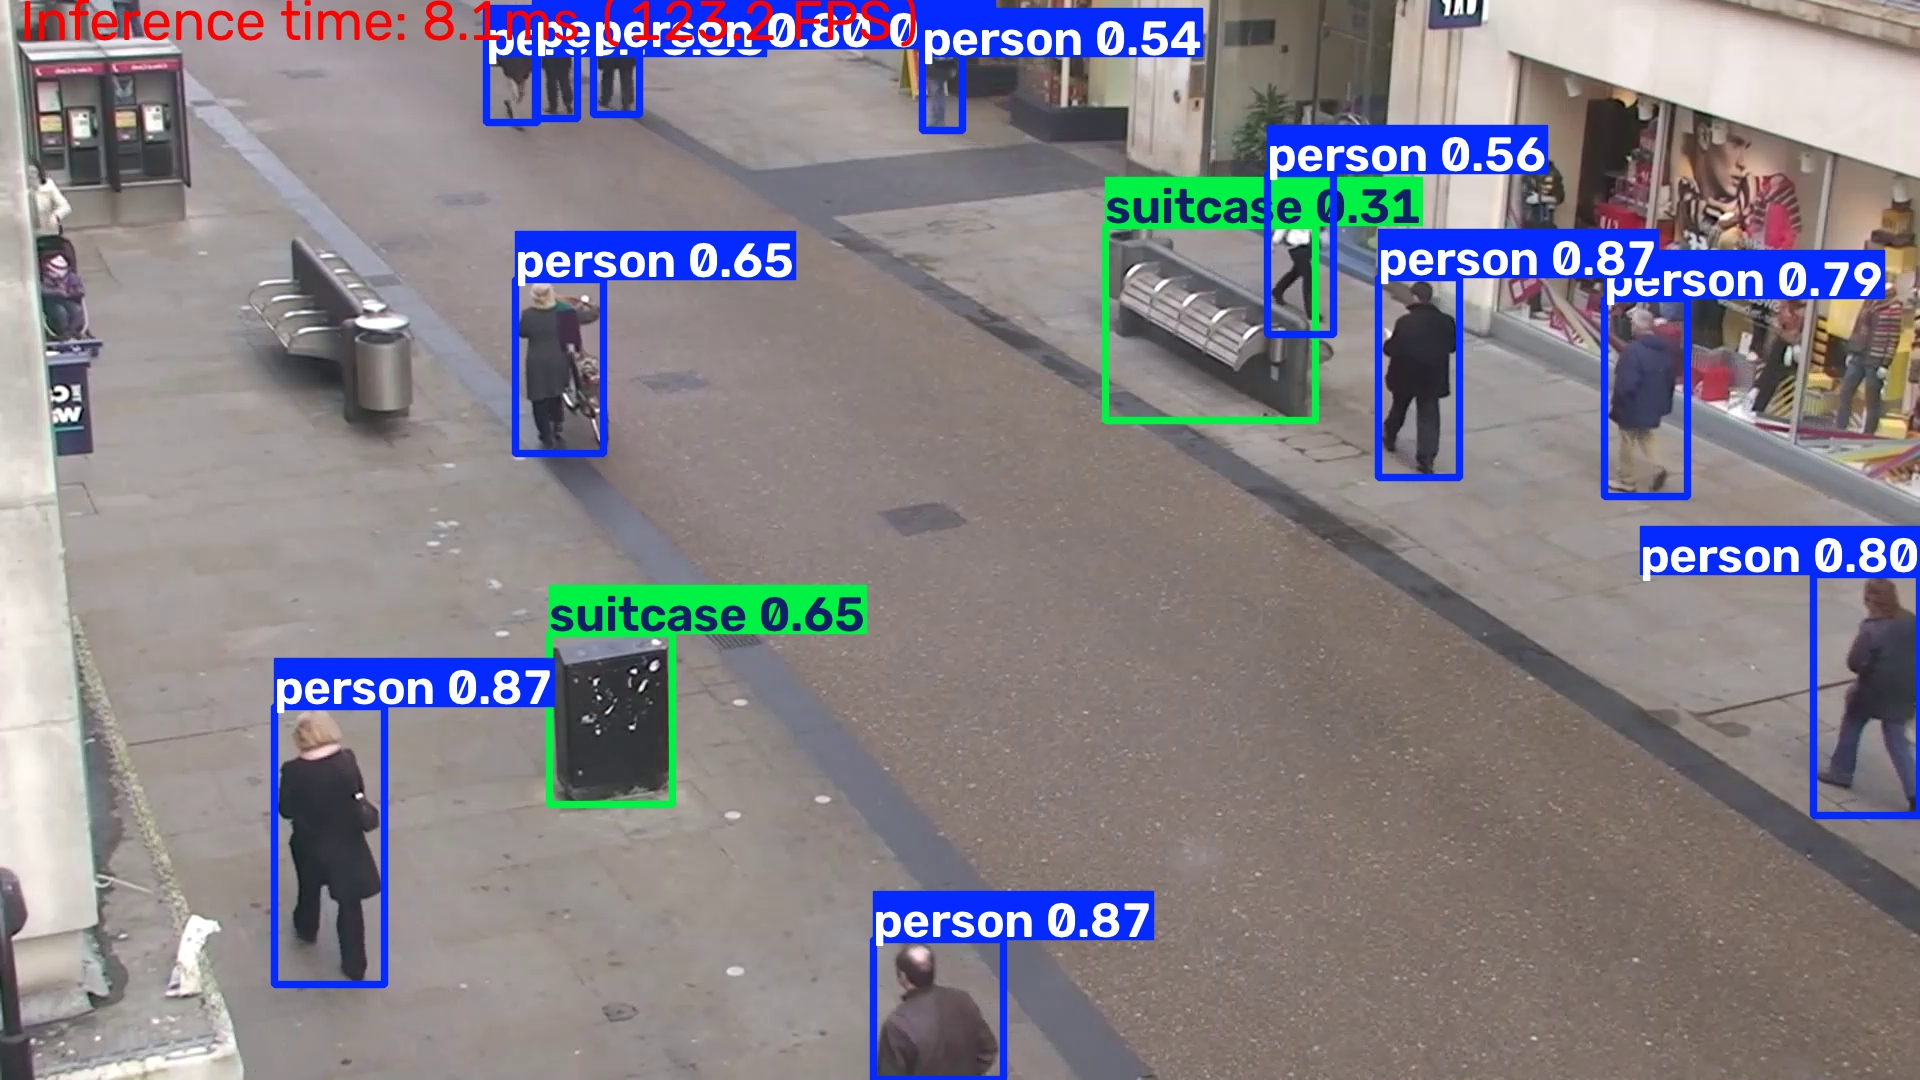

Source ended


In [20]:
run_object_detection(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=False,
    model=det_model,
    device=device.value,
    # video_width=1280,
)